# Studi Kasus 2: Klasifikasi Teks SMS Spam Menggunakan Multinomial Naive Bayes
**Mata Kuliah:** Pembelajaran Mesin  
**Dataset:** `Dataset/spam.csv`  
**Algoritma:** Multinomial Naive Bayes (`MultinomialNB`)  
**Eksperimen Fitur:** `CountVectorizer` vs. `TfidfVectorizer` (keduanya dengan `stop_words='english'`)  
**Strategi Validasi:** Stratified Train-Test Split (80:20, `stratify=y`, `random_state=50`)

---
### 📌 Ringkasan Tugas & Tujuan Praktikum:
1. **Tugas 2:** Membangun model klasifikasi teks Multinomial Naive Bayes menggunakan representasi fitur **CountVectorizer** dengan mengaktifkan parameter `stop_words='english'` pada data `spam.csv`, serta mengevaluasi performanya secara menyeluruh.
2. **Tugas 3:** Membangun model klasifikasi teks Multinomial Naive Bayes menggunakan representasi fitur **TF-IDF (TfidfVectorizer)** dengan mengaktifkan parameter `stop_words='english'` pada data `spam.csv`, mengevaluasi hasilnya, dan membandingkannya dengan hasil pada Tugas 2.
3. **Penerapan Metodologi Best Practice (`stratify=y`):** Menganalisis mengapa pembagian data pada teks berketidakseimbangan kelas (*class imbalance*) wajib menggunakan `stratify=y` guna menjaga cakupan kosakata (*vocabulary coverage*) dan kestabilan pembobotan frekuensi kata.
4. **Kesimpulan Komparatif:** Memberikan kesimpulan ilmiah dan praktis mengenai fitur representasi teks mana yang terbaik pada kasus data `spam.csv`.


---
## 1: Eksplorasi Data (EDA) & Analisis Karakteristik Teks
Pada tahap awal, kita memuat dataset `spam.csv`, menganalisis kelengkapan data, membersihkan kolom artefak, serta mengidentifikasi ketidakseimbangan kelas target (`ham` vs `spam`).


In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Konfigurasi visualisasi
plt.style.use('seaborn-v0_8-whitegrid' if 'seaborn-v0_8-whitegrid' in plt.style.available else 'default')
plt.rcParams['font.sans-serif'] = 'DejaVu Sans'
plt.rcParams['figure.dpi'] = 100

# 1. Load Dataset dengan penanganan encoding latin-1
df = pd.read_csv('Dataset/spam.csv', encoding='latin-1')

print(f"Dimensi awal dataset: {df.shape[0]} baris x {df.shape[1]} kolom")
df.head()


Dimensi awal dataset: 5572 baris x 5 kolom


,v1,v2,Unnamed: 2,Unnamed: 3,Unnamed: 4
0,ham,"Go until jurong point, crazy.. Available only ...",NaN,NaN,NaN
1,ham,Ok lar... Joking wif u oni...,NaN,NaN,NaN
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...,NaN,NaN,NaN
3,ham,U dun say so early hor... U c already then say...,NaN,NaN,NaN
4,ham,"Nah I don't think he goes to usf, he lives aro...",NaN,NaN,NaN


### Pembersihan Kolom Artefak & Penamaan Ulang Kolom
Dataset asli memiliki 3 kolom kosong tambahan (`Unnamed: 2`, `Unnamed: 3`, `Unnamed: 4`) akibat pemisahan tanda koma dalam teks SMS. Kita bersihkan kolom-kolom tersebut dan menamai ulang kolom `v1` menjadi `Labels` dan `v2` menjadi `SMS`.


In [4]:
# Drop 3 kolom terakhir yang tidak digunakan
df = df.drop(df.iloc[:, 2:], axis=1)

# Rename kolom agar lebih representatif
df = df.rename(columns={'v1': 'Labels', 'v2': 'SMS'})

# Cek informasi dan kelengkapan data
print("Informasi Dataset setelah pembersihan:")
print(df.info())
print("\nJumlah Missing Values per Kolom:")
print(df.isnull().sum())
df.head()


Informasi Dataset setelah pembersihan:
<class 'pandas.DataFrame'>
RangeIndex: 5572 entries, 0 to 5571
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype
---  ------  --------------  -----
 0   Labels  5572 non-null   str  
 1   SMS     5572 non-null   str  
dtypes: str(2)
memory usage: 541.4 KB
None

Jumlah Missing Values per Kolom:
Labels    0
SMS       0
dtype: int64


,Labels,SMS
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."


### Analisis Distribusi Kelas Target & Karakteristik Teks
Mari kita periksa proporsi kelas `ham` (pesan normal) dan `spam` (pesan sampah/iklan), serta menganalisis perbedaan panjang karakter dan jumlah kata antara kedua kelas.


In [5]:
# Hitung distribusi frekuensi dan persentase kelas
counts = df['Labels'].value_counts()
percentages = df['Labels'].value_counts(normalize=True) * 100

dist_df = pd.DataFrame({
    'Jumlah Pesan': counts,
    'Persentase (%)': percentages.round(2)
})
print("Distribusi Kelas Target:")
print(dist_df)

# Rekayasa fitur sederhana untuk analisis teks: panjang karakter & jumlah kata
df['char_length'] = df['SMS'].apply(len)
df['word_count'] = df['SMS'].apply(lambda x: len(x.split()))

print("\nStatistik Deskriptif Karakteristik Pesan (Ham vs Spam):")
print(df.groupby('Labels')[['char_length', 'word_count']].agg(['mean', 'median', 'std', 'max']))


Distribusi Kelas Target:
        Jumlah Pesan  Persentase (%)
Labels                              
ham             4825           86.59
spam             747           13.41

Statistik Deskriptif Karakteristik Pesan (Ham vs Spam):
       char_length                        word_count                       
              mean median        std  max       mean median        std  max
Labels                                                                     
ham      71.023627   52.0  58.016023  910  14.200622   11.0  11.424511  171
spam    138.866131  149.0  29.183082  224  23.851406   25.0   5.811898   35


C:\Users\lianb\AppData\Local\Temp\ipykernel_22108\3424132507.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=dist_df.index, y='Jumlah Pesan', data=dist_df, ax=axes[0], palette=['#2b5c8f', '#d9534f'])
C:\Users\lianb\AppData\Local\Temp\ipykernel_22108\3424132507.py:22: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='Labels', y='word_count', ax=axes[2], palette=palette)


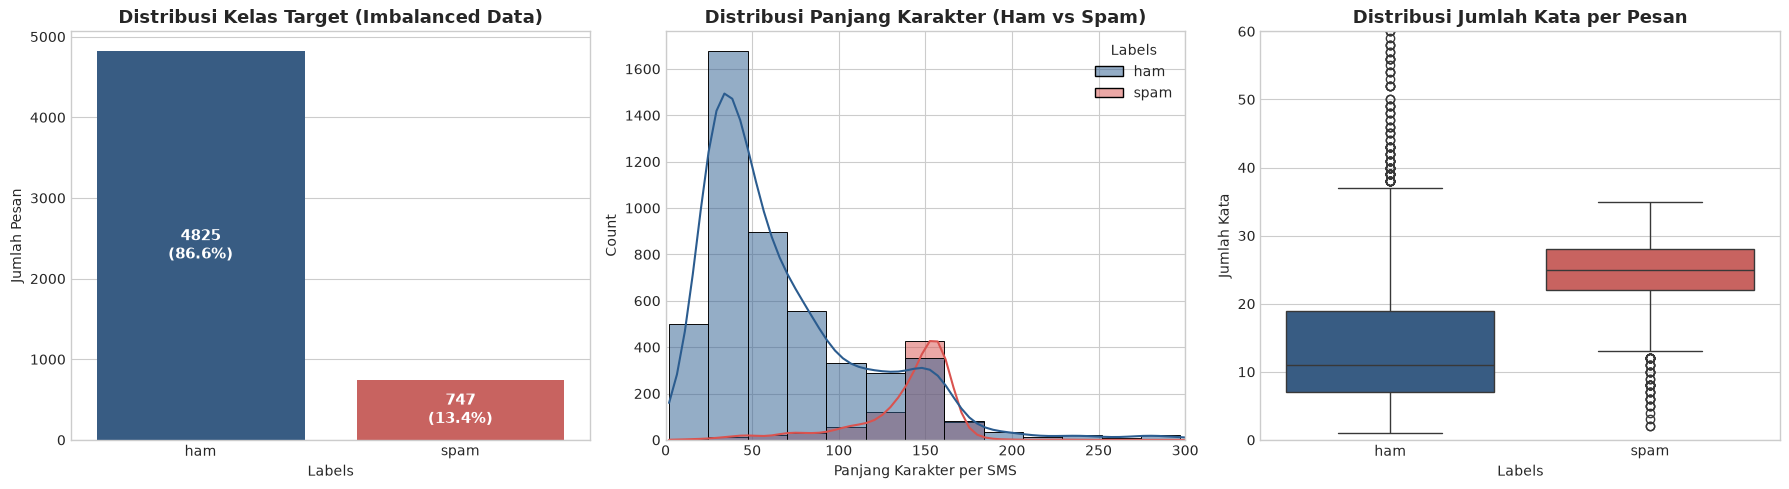

In [6]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Plot 1: Distribusi Kelas Target
palette = {'ham': '#2b5c8f', 'spam': '#d9534f'}
sns.barplot(x=dist_df.index, y='Jumlah Pesan', data=dist_df, ax=axes[0], palette=['#2b5c8f', '#d9534f'])
axes[0].set_title('Distribusi Kelas Target (Imbalanced Data)', fontsize=13, fontweight='bold')
axes[0].set_ylabel('Jumlah Pesan')
for p in axes[0].patches:
    val = int(p.get_height())
    pct = val / len(df) * 100
    axes[0].annotate(f"{val}\n({pct:.1f}%)",
                     (p.get_x() + p.get_width() / 2., p.get_height() / 2),
                     ha='center', va='center', color='white', fontweight='bold', fontsize=11)

# Plot 2: Distribusi Panjang Karakter (Histplot + KDE)
sns.histplot(data=df, x='char_length', hue='Labels', bins=40, kde=True, ax=axes[1], palette=palette)
axes[1].set_title('Distribusi Panjang Karakter (Ham vs Spam)', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Panjang Karakter per SMS')
axes[1].set_xlim(0, 300)

# Plot 3: Boxplot Jumlah Kata
sns.boxplot(data=df, x='Labels', y='word_count', ax=axes[2], palette=palette)
axes[2].set_title('Distribusi Jumlah Kata per Pesan', fontsize=13, fontweight='bold')
axes[2].set_ylabel('Jumlah Kata')
axes[2].set_ylim(0, 60)

plt.tight_layout()
plt.show()


---
## 2: Data Preprocessing & Splitting (Penerapan `stratify=y`)

### 🧠 Mengapa Wajib Menggunakan `stratify=y` pada Ekstraksi Fitur Teks?
Dataset ini mengalami ketidakseimbangan kelas (*class imbalance*) yang signifikan:
- **Ham**: 4.825 pesan (**86.59%**)
- **Spam**: 747 pesan (**13.41%**)

Pada ekstraksi fitur teks (`CountVectorizer` dan `TF-IDF`), ketiadaan stratifikasi sangat berisiko:
1. **Cakupan Kosakata (*Vocabulary Coverage*)**: Kosakata unik spam (*claim, prize, 150p, win, txt*) hanya berjumlah 747 sampel. Jika di-split secara acak murni, sampel spam di `X_train` bisa berkurang drastis, sehingga kata-kata penting spam tidak masuk ke kamus kosakata (`vocabulary_`) saat `fit_transform()`. Pada data uji, kata-kata tersebut akan dianggap *Out-of-Vocabulary* (OOV) dan diabaikan!
2. **Kestabilan Pembobotan IDF**: Nilai Inverse Document Frequency $\text{IDF}(t) = \ln\left(\frac{1+n}{1+\text{df}(t)}\right)+1$ dihitung dari data latih. Fluktuasi rasio spam di train akan merusak bobot diskriminatif IDF.
3. **Kestabilan Prior Probability**: MultinomialNB menghitung $P(\text{Spam}) = \frac{N_{\text{spam}}}{N_{\text{total}}}$. Menggunakan `stratify=y` menjamin proporsi prior di train dan test terkunci presisi di angka **13.41%**.

### Prinsip Pencegahan Kebocoran Data (*Anti-Data Leakage*):
Pemisahan data dilakukan **sebelum** proses vektorisasi teks. `fit_transform` hanya dijalankan pada `X_train`, sedangkan `X_test` hanya di-`transform`.


In [7]:
from sklearn.model_selection import train_test_split

# 1. Encoding label kategori menjadi numerik
label_mapping = {'ham': 0, 'spam': 1}
df['Labels_num'] = df['Labels'].map(label_mapping)

# Pisahkan variabel fitur (teks mentah) dan target sebagai numpy array
X = df['SMS'].to_numpy()
y = df['Labels_num'].to_numpy()

# 2. Split dataset 80% Train dan 20% Test dengan stratify=y
X_train_raw, X_test_raw, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=50, stratify=y
)

print(f"Total Sampel Data Latih (X_train) : {len(X_train_raw)} baris")
print(f"Total Sampel Data Uji   (X_test)  : {len(X_test_raw)} baris")
print(f"Proporsi Spam di Data Latih (Train) : {np.mean(y_train)*100:.2f}% ({np.sum(y_train)} spam / {len(y_train)-np.sum(y_train)} ham)")
print(f"Proporsi Spam di Data Uji   (Test)  : {np.mean(y_test)*100:.2f}% ({np.sum(y_test)} spam / {len(y_test)-np.sum(y_test)} ham)")


Total Sampel Data Latih (X_train) : 4457 baris
Total Sampel Data Uji   (X_test)  : 1115 baris
Proporsi Spam di Data Latih (Train) : 13.42% (598 spam / 3859 ham)
Proporsi Spam di Data Uji   (Test)  : 13.36% (149 spam / 966 ham)


---
## 3: Pemodelan 1 — Multinomial Naive Bayes dengan CountVectorizer (stop_words='english')

### 📌 Ketentuan Tugas 2:
> Buatlah model klasifikasi Multinomial Naive Bayes dengan ketentuan:
> 1. Menggunakan data `spam.csv`
> 2. Fitur `CountVectorizer` dengan mengaktifkan parameter `stop_words='english'`
> 3. Evaluasi hasilnya secara lengkap

### Penjelasan Metode & Peran Stop Words:
- **CountVectorizer (Bag of Words)**: Mengubah dokumen teks menjadi matriks frekuensi kemunculan kata (*word count matrix*). Nilai fiturnya adalah bilangan bulat non-negatif ($x_{ij} \in \mathbb{N}_0$) yang secara matematis cocok dengan distribusi multinomial.
- **Parameter `stop_words='english'`**: Menghapus 318 kata umum bahasa Inggris (seperti *the, is, in, at, which, an, and*) yang muncul di hampir semua dokumen tanpa nilai diskriminatif. Hal ini memangkas dimensi kosakata (*vocabulary pruning*) serta menghilangkan derau (*noise*).


In [8]:
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report

# 1. Inisialisasi CountVectorizer dengan mengaktifkan stop_words='english'
cv = CountVectorizer(stop_words='english')

# 2. Fit dan transform pada X_train, serta transform pada X_test
X_train_cv = cv.fit_transform(X_train_raw)
X_test_cv = cv.transform(X_test_raw)

# Analisis dimensi kosakata
vocab_cv_size = len(cv.get_feature_names_out())
print(f"Jumlah kosakata unik (Vocabulary Size) CountVectorizer: {vocab_cv_size} kata")
print(f"Bentuk matriks X_train_cv : {X_train_cv.shape}")
print(f"Bentuk matriks X_test_cv  : {X_test_cv.shape}")

# 3. Inisialisasi dan pelatihan model Multinomial Naive Bayes
mnb_cv = MultinomialNB()
mnb_cv.fit(X_train_cv, y_train)

# 4. Prediksi pada data latih dan data uji
y_train_pred_cv = mnb_cv.predict(X_train_cv)
y_test_pred_cv = mnb_cv.predict(X_test_cv)

# 5. Evaluasi metrik performa
acc_train_cv = accuracy_score(y_train, y_train_pred_cv)
acc_test_cv = accuracy_score(y_test, y_test_pred_cv)
prec_cv = precision_score(y_test, y_test_pred_cv)
rec_cv = recall_score(y_test, y_test_pred_cv)
f1_cv = f1_score(y_test, y_test_pred_cv)
cm_cv = confusion_matrix(y_test, y_test_pred_cv)

print("\n=================================================================")
print("HASIL EVALUASI TUGAS 2: MULTINOMIAL NB + COUNT VECTORIZER (+STOP WORDS)")
print("=================================================================")
print(f"Akurasi Data Latih (Train Accuracy) : {acc_train_cv:.4f} ({acc_train_cv*100:.2f}%)")
print(f"Akurasi Data Uji   (Test Accuracy)  : {acc_test_cv:.4f} ({acc_test_cv*100:.2f}%)")
print(f"Spam Precision                       : {prec_cv:.4f} ({prec_cv*100:.2f}%)")
print(f"Spam Recall                          : {rec_cv:.4f} ({rec_cv*100:.2f}%)")
print(f"Spam F1-Score                        : {f1_cv:.4f} ({f1_cv*100:.2f}%)")
print("\nConfusion Matrix (Test Set):")
print(cm_cv)
print("\nClassification Report (Test Set):")
print(classification_report(y_test, y_test_pred_cv, target_names=['Ham (0)', 'Spam (1)'], digits=4))


Jumlah kosakata unik (Vocabulary Size) CountVectorizer: 7422 kata
Bentuk matriks X_train_cv : (4457, 7422)
Bentuk matriks X_test_cv  : (1115, 7422)

HASIL EVALUASI TUGAS 2: MULTINOMIAL NB + COUNT VECTORIZER (+STOP WORDS)
Akurasi Data Latih (Train Accuracy) : 0.9939 (99.39%)
Akurasi Data Uji   (Test Accuracy)  : 0.9821 (98.21%)
Spam Precision                       : 0.9574 (95.74%)
Spam Recall                          : 0.9060 (90.60%)
Spam F1-Score                        : 0.9310 (93.10%)

Confusion Matrix (Test Set):
[[960   6]
 [ 14 135]]

Classification Report (Test Set):
              precision    recall  f1-score   support

     Ham (0)     0.9856    0.9938    0.9897       966
    Spam (1)     0.9574    0.9060    0.9310       149

    accuracy                         0.9821      1115
   macro avg     0.9715    0.9499    0.9604      1115
weighted avg     0.9819    0.9821    0.9819      1115



---
## 4: Pemodelan 2 — Multinomial Naive Bayes dengan TF-IDF (stop_words='english')

### 📌 Ketentuan Tugas 3:
> Buatlah model klasifikasi Multinomial Naive Bayes dengan ketentuan:
> 1. Menggunakan data `spam.csv`
> 2. Fitur `TF-IDF` dengan mengaktifkan parameter `stop_words='english'`
> 3. Evaluasi hasilnya dan bandingkan dengan hasil pada Tugas no 2.
> 4. Berikan kesimpulan fitur mana yang terbaik pada kasus data `spam.csv`.

### Penjelasan Metode TF-IDF (Term Frequency - Inverse Document Frequency):
Berbeda dengan CountVectorizer yang hanya mengandalkan hitungan frekuensi mentah, TF-IDF memberikan bobot relatif berdasarkan tingkat kekhususan kata:
1. **Term Frequency (TF)**: Frekuensi kemunculan kata $t$ dalam dokumen $d$.
2. **Inverse Document Frequency (IDF)**: Menghukum kata yang terlalu sering muncul di banyak dokumen dan mengapresiasi kata langka:
   $$\text{IDF}(t) = \ln\left(\frac{1 + n}{1 + \text{df}(t)}\right) + 1$$
3. **Normalisasi L2**: Setiap vektor dokumen dinormalisasi ke satuan panjang Euclidean ($||x||_2 = 1$), menghasilkan nilai pecahan desimal kontinu ($x_{ij} \in [0, 1]$).


In [9]:
from sklearn.feature_extraction.text import TfidfVectorizer

# 1. Inisialisasi TfidfVectorizer dengan stop_words='english'
tfidf = TfidfVectorizer(stop_words='english')

# 2. Fit dan transform pada data latih, transform pada data uji
X_train_tfidf = tfidf.fit_transform(X_train_raw)
X_test_tfidf = tfidf.transform(X_test_raw)

# Analisis dimensi kosakata
vocab_tfidf_size = len(tfidf.get_feature_names_out())
print(f"Jumlah kosakata unik (Vocabulary Size) TF-IDF: {vocab_tfidf_size} kata")
print(f"Bentuk matriks X_train_tfidf : {X_train_tfidf.shape}")
print(f"Bentuk matriks X_test_tfidf  : {X_test_tfidf.shape}")

# 3. Inisialisasi dan pelatihan model Multinomial Naive Bayes
mnb_tfidf = MultinomialNB()
mnb_tfidf.fit(X_train_tfidf, y_train)

# 4. Prediksi pada data latih dan data uji
y_train_pred_tfidf = mnb_tfidf.predict(X_train_tfidf)
y_test_pred_tfidf = mnb_tfidf.predict(X_test_tfidf)

# 5. Evaluasi metrik performa
acc_train_tfidf = accuracy_score(y_train, y_train_pred_tfidf)
acc_test_tfidf = accuracy_score(y_test, y_test_pred_tfidf)
prec_tfidf = precision_score(y_test, y_test_pred_tfidf)
rec_tfidf = recall_score(y_test, y_test_pred_tfidf)
f1_tfidf = f1_score(y_test, y_test_pred_tfidf)
cm_tfidf = confusion_matrix(y_test, y_test_pred_tfidf)

print("\n=================================================================")
print("HASIL EVALUASI TUGAS 3: MULTINOMIAL NB + TF-IDF (+STOP WORDS)")
print("=================================================================")
print(f"Akurasi Data Latih (Train Accuracy) : {acc_train_tfidf:.4f} ({acc_train_tfidf*100:.2f}%)")
print(f"Akurasi Data Uji   (Test Accuracy)  : {acc_test_tfidf:.4f} ({acc_test_tfidf*100:.2f}%)")
print(f"Spam Precision                       : {prec_tfidf:.4f} ({prec_tfidf*100:.2f}%)")
print(f"Spam Recall                          : {rec_tfidf:.4f} ({rec_tfidf*100:.2f}%)")
print(f"Spam F1-Score                        : {f1_tfidf:.4f} ({f1_tfidf*100:.2f}%)")
print("\nConfusion Matrix (Test Set):")
print(cm_tfidf)
print("\nClassification Report (Test Set):")
print(classification_report(y_test, y_test_pred_tfidf, target_names=['Ham (0)', 'Spam (1)'], digits=4))


Jumlah kosakata unik (Vocabulary Size) TF-IDF: 7422 kata
Bentuk matriks X_train_tfidf : (4457, 7422)
Bentuk matriks X_test_tfidf  : (1115, 7422)

HASIL EVALUASI TUGAS 3: MULTINOMIAL NB + TF-IDF (+STOP WORDS)
Akurasi Data Latih (Train Accuracy) : 0.9843 (98.43%)
Akurasi Data Uji   (Test Accuracy)  : 0.9731 (97.31%)
Spam Precision                       : 1.0000 (100.00%)
Spam Recall                          : 0.7987 (79.87%)
Spam F1-Score                        : 0.8881 (88.81%)

Confusion Matrix (Test Set):
[[966   0]
 [ 30 119]]

Classification Report (Test Set):
              precision    recall  f1-score   support

     Ham (0)     0.9699    1.0000    0.9847       966
    Spam (1)     1.0000    0.7987    0.8881       149

    accuracy                         0.9731      1115
   macro avg     0.9849    0.8993    0.9364      1115
weighted avg     0.9739    0.9731    0.9718      1115



---
## 5: Komparasi Menyeluruh: CountVectorizer (Tugas 2) vs. TF-IDF (Tugas 3)

Pada tahap ini, kita menyandingkan metrik performa kedua model, mengevaluasi matriks kebingungan (*confusion matrix*), memvisualisasikan trade-off Precision-Recall / ROC curve, serta menganalisis perbandingan performa jika menggunakan split tanpa stratify vs dengan stratify.


In [16]:
# Susun dataframe tabel perbandingan komparatif utama
from IPython.display import display
comparison_dict = {
    'Metrik Evaluasi': [
        'Ukuran Kosakata (Vocab Size)',
        'Akurasi Data Latih (Train Acc)',
        'Akurasi Data Uji (Test Acc)',
        'Spam Precision',
        'Spam Recall',
        'Spam F1-Score',
        'Macro Avg F1-Score',
        'Weighted Avg F1-Score',
        'True Negatives (TN - Ham Benar)',
        'False Positives (FP - Ham dituduh Spam)',
        'False Negatives (FN - Spam lolos Inbox)',
        'True Positives (TP - Spam Terdeteksi)'
    ],
    'Tugas 2: CountVectorizer (+StopWords)': [
        vocab_cv_size,
        f"{acc_train_cv*100:.2f}%",
        f"{acc_test_cv*100:.2f}%",
        f"{prec_cv*100:.2f}%",
        f"{rec_cv*100:.2f}%",
        f"{f1_cv*100:.2f}%",
        f"{f1_score(y_test, y_test_pred_cv, average='macro')*100:.2f}%",
        f"{f1_score(y_test, y_test_pred_cv, average='weighted')*100:.2f}%",
        cm_cv[0, 0],
        cm_cv[0, 1],
        cm_cv[1, 0],
        cm_cv[1, 1]
    ],
    'Tugas 3: TF-IDF (+StopWords)': [
        vocab_tfidf_size,
        f"{acc_train_tfidf*100:.2f}%",
        f"{acc_test_tfidf*100:.2f}%",
        f"{prec_tfidf*100:.2f}%",
        f"{rec_tfidf*100:.2f}%",
        f"{f1_tfidf*100:.2f}%",
        f"{f1_score(y_test, y_test_pred_tfidf, average='macro')*100:.2f}%",
        f"{f1_score(y_test, y_test_pred_tfidf, average='weighted')*100:.2f}%",
        cm_tfidf[0, 0],
        cm_tfidf[0, 1],
        cm_tfidf[1, 0],
        cm_tfidf[1, 1]
    ]
}

comp_df = pd.DataFrame(comparison_dict)
display(comp_df)


,Metrik Evaluasi,Tugas 2: CountVectorizer (+StopWords),Tugas 3: TF-IDF (+StopWords)
0,Ukuran Kosakata (Vocab Size),7422,7422
1,Akurasi Data Latih (Train Acc),99.39%,98.43%
2,Akurasi Data Uji (Test Acc),98.21%,97.31%
3,Spam Precision,95.74%,100.00%
4,Spam Recall,90.60%,79.87%
5,Spam F1-Score,93.10%,88.81%
6,Macro Avg F1-Score,96.04%,93.64%
7,Weighted Avg F1-Score,98.19%,97.18%
8,True Negatives (TN - Ham Benar),960,966
9,False Positives (FP - Ham dituduh Spam),6,0


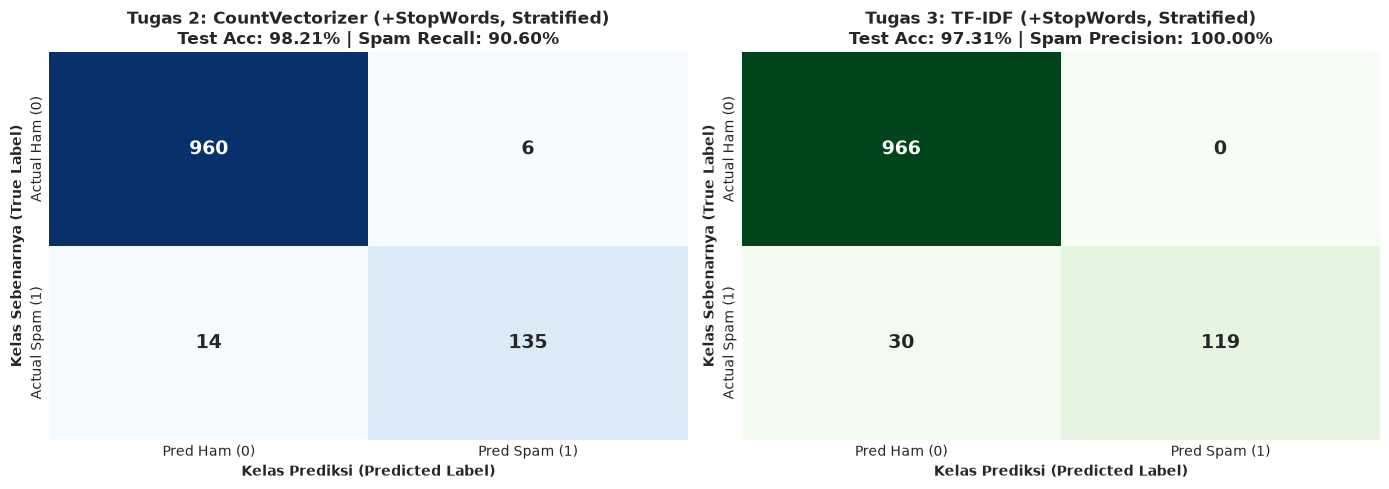

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Heatmap Model 1: CountVectorizer
sns.heatmap(cm_cv, annot=True, fmt='d', cmap='Blues', ax=axes[0], cbar=False, annot_kws={'size': 14, 'weight': 'bold'},
            xticklabels=['Pred Ham (0)', 'Pred Spam (1)'], yticklabels=['Actual Ham (0)', 'Actual Spam (1)'])
axes[0].set_title(f'Tugas 2: CountVectorizer (+StopWords, Stratified)\nTest Acc: {acc_test_cv*100:.2f}% | Spam Recall: {rec_cv*100:.2f}%', fontsize=12, fontweight='bold')
axes[0].set_ylabel('Kelas Sebenarnya (True Label)', fontweight='bold')
axes[0].set_xlabel('Kelas Prediksi (Predicted Label)', fontweight='bold')

# Heatmap Model 2: TF-IDF
sns.heatmap(cm_tfidf, annot=True, fmt='d', cmap='Greens', ax=axes[1], cbar=False, annot_kws={'size': 14, 'weight': 'bold'},
            xticklabels=['Pred Ham (0)', 'Pred Spam (1)'], yticklabels=['Actual Ham (0)', 'Actual Spam (1)'])
axes[1].set_title(f'Tugas 3: TF-IDF (+StopWords, Stratified)\nTest Acc: {acc_test_tfidf*100:.2f}% | Spam Precision: {prec_tfidf*100:.2f}%', fontsize=12, fontweight='bold')
axes[1].set_ylabel('Kelas Sebenarnya (True Label)', fontweight='bold')
axes[1].set_xlabel('Kelas Prediksi (Predicted Label)', fontweight='bold')

plt.tight_layout()
plt.show()


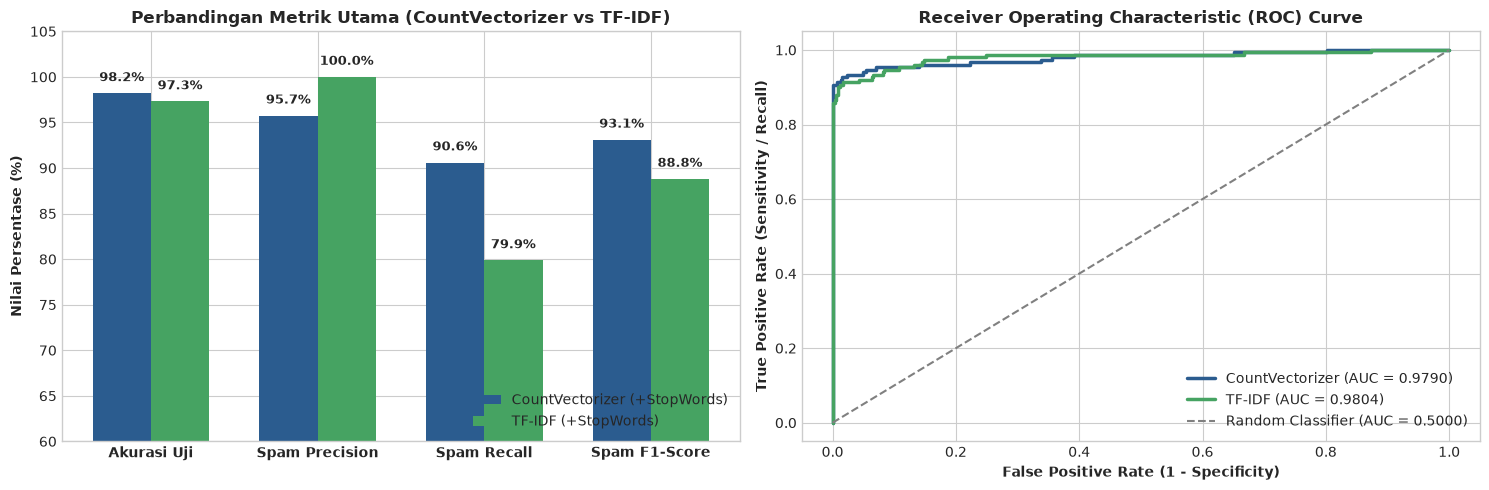

In [12]:
from sklearn.metrics import roc_curve, auc

# Dapatkan probabilitas positif (spam) dari kedua model
y_prob_cv = mnb_cv.predict_proba(X_test_cv)[:, 1]
y_prob_tfidf = mnb_tfidf.predict_proba(X_test_tfidf)[:, 1]

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# 1. Bar Chart Komparasi Metrik Evaluasi
metrics_names = ['Akurasi Uji', 'Spam Precision', 'Spam Recall', 'Spam F1-Score']
scores_cv = [acc_test_cv * 100, prec_cv * 100, rec_cv * 100, f1_cv * 100]
scores_tfidf = [acc_test_tfidf * 100, prec_tfidf * 100, rec_tfidf * 100, f1_tfidf * 100]

x = np.arange(len(metrics_names))
width = 0.35

rects1 = axes[0].bar(x - width/2, scores_cv, width, label='CountVectorizer (+StopWords)', color='#2b5c8f')
rects2 = axes[0].bar(x + width/2, scores_tfidf, width, label='TF-IDF (+StopWords)', color='#46a362')

axes[0].set_title('Perbandingan Metrik Utama (CountVectorizer vs TF-IDF)', fontsize=12, fontweight='bold')
axes[0].set_ylabel('Nilai Persentase (%)', fontweight='bold')
axes[0].set_xticks(x)
axes[0].set_xticklabels(metrics_names, fontweight='bold')
axes[0].set_ylim(60, 105)
axes[0].legend(loc='lower right')

for rect in rects1:
    h = rect.get_height()
    axes[0].annotate(f'{h:.1f}%', (rect.get_x() + rect.get_width() / 2, h + 1), ha='center', va='bottom', fontsize=9, fontweight='bold')
for rect in rects2:
    h = rect.get_height()
    axes[0].annotate(f'{h:.1f}%', (rect.get_x() + rect.get_width() / 2, h + 1), ha='center', va='bottom', fontsize=9, fontweight='bold')

# 2. Kurva ROC & Nilai AUC
fpr_cv, tpr_cv, _ = roc_curve(y_test, y_prob_cv)
fpr_tfidf, tpr_tfidf, _ = roc_curve(y_test, y_prob_tfidf)
auc_cv = auc(fpr_cv, tpr_cv)
auc_tfidf = auc(fpr_tfidf, tpr_tfidf)

axes[1].plot(fpr_cv, tpr_cv, color='#2b5c8f', lw=2.5, label=f'CountVectorizer (AUC = {auc_cv:.4f})')
axes[1].plot(fpr_tfidf, tpr_tfidf, color='#46a362', lw=2.5, label=f'TF-IDF (AUC = {auc_tfidf:.4f})')
axes[1].plot([0, 1], [0, 1], color='gray', linestyle='--', label='Random Classifier (AUC = 0.5000)')
axes[1].set_title('Receiver Operating Characteristic (ROC) Curve', fontsize=12, fontweight='bold')
axes[1].set_xlabel('False Positive Rate (1 - Specificity)', fontweight='bold')
axes[1].set_ylabel('True Positive Rate (Sensitivity / Recall)', fontweight='bold')
axes[1].legend(loc='lower right')

plt.tight_layout()
plt.show()


In [13]:
# Analisis Tambahan: Pembuktian Ilmiah Dampak Stratify vs Tanpa Stratify
# Split tanpa stratify untuk perbandingan
X_tr_ns, X_te_ns, y_tr_ns, y_te_ns = train_test_split(X, y, test_size=0.2, random_state=50)

# CountVectorizer tanpa stratify
cv_ns = CountVectorizer(stop_words='english')
m_cv_ns = MultinomialNB().fit(cv_ns.fit_transform(X_tr_ns), y_tr_ns)
p_cv_ns = m_cv_ns.predict(cv_ns.transform(X_te_ns))

# TF-IDF tanpa stratify
tf_ns = TfidfVectorizer(stop_words='english')
m_tf_ns = MultinomialNB().fit(tf_ns.fit_transform(X_tr_ns), y_tr_ns)
p_tf_ns = m_tf_ns.predict(tf_ns.transform(X_te_ns))

strat_comparison = pd.DataFrame({
    'Fitur & Strategi Split': [
        'CountVectorizer (Tanpa Stratify)',
        'CountVectorizer (Dengan Stratify=y)',
        'TF-IDF (Tanpa Stratify)',
        'TF-IDF (Dengan Stratify=y)'
    ],
    'Proporsi Spam Train': [
        f"{np.mean(y_tr_ns)*100:.2f}%", f"{np.mean(y_train)*100:.2f}%",
        f"{np.mean(y_tr_ns)*100:.2f}%", f"{np.mean(y_train)*100:.2f}%"
    ],
    'Proporsi Spam Test': [
        f"{np.mean(y_te_ns)*100:.2f}%", f"{np.mean(y_test)*100:.2f}%",
        f"{np.mean(y_te_ns)*100:.2f}%", f"{np.mean(y_test)*100:.2f}%"
    ],
    'Test Accuracy': [
        f"{accuracy_score(y_te_ns, p_cv_ns)*100:.2f}%", f"{acc_test_cv*100:.2f}%",
        f"{accuracy_score(y_te_ns, p_tf_ns)*100:.2f}%", f"{acc_test_tfidf*100:.2f}%"
    ],
    'Spam Precision': [
        f"{precision_score(y_te_ns, p_cv_ns)*100:.2f}%", f"{prec_cv*100:.2f}%",
        f"{precision_score(y_te_ns, p_tf_ns)*100:.2f}%", f"{prec_tfidf*100:.2f}%"
    ],
    'Spam Recall': [
        f"{recall_score(y_te_ns, p_cv_ns)*100:.2f}%", f"{rec_cv*100:.2f}%",
        f"{recall_score(y_te_ns, p_tf_ns)*100:.2f}%", f"{rec_tfidf*100:.2f}%"
    ],
    'Spam F1-Score': [
        f"{f1_score(y_te_ns, p_cv_ns)*100:.2f}%", f"{f1_cv*100:.2f}%",
        f"{f1_score(y_te_ns, p_tf_ns)*100:.2f}%", f"{f1_tfidf*100:.2f}%"
    ]
})

print("Tabel Pembuktian: Dampak Penggunaan stratify=y Terhadap Representasi Fitur:")
display(strat_comparison)


Tabel Pembuktian: Dampak Penggunaan stratify=y Terhadap Representasi Fitur:


,Fitur & Strategi Split,Proporsi Spam Train,Proporsi Spam Test,Test Accuracy,Spam Precision,Spam Recall,Spam F1-Score
0,CountVectorizer (Tanpa Stratify),13.15%,14.44%,98.30%,97.97%,90.06%,93.85%
1,CountVectorizer (Dengan Stratify=y),13.42%,13.36%,98.21%,95.74%,90.60%,93.10%
2,TF-IDF (Tanpa Stratify),13.15%,14.44%,96.05%,100.00%,72.67%,84.17%
3,TF-IDF (Dengan Stratify=y),13.42%,13.36%,97.31%,100.00%,79.87%,88.81%


---
## 6: Analisis Kata Kunci Paling Berpengaruh (Top Informative Features)

Untuk membuktikan secara linguistik dan statistik bagaimana Multinomial Naive Bayes mengenali pesan Spam dan Ham, kita mengekstraksi kata-kata dengan rasio log-likelihood tertinggi:
$$\text{Log-Odds Ratio}(w) = \log P(w \mid \text{Spam}) - \log P(w \mid \text{Ham})$$


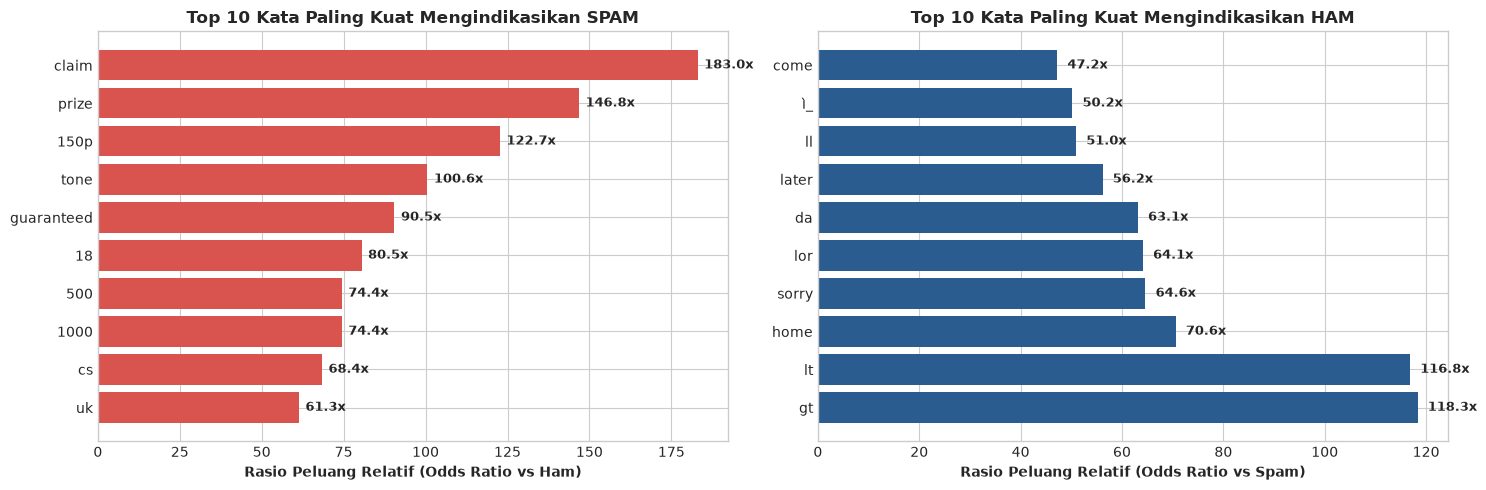

In [14]:
feature_names = cv.get_feature_names_out()

# Ambil log feature probability untuk Spam (kelas 1) dan Ham (kelas 0)
log_prob_spam = mnb_cv.feature_log_prob_[1]
log_prob_ham = mnb_cv.feature_log_prob_[0]

# Selisih log-probabilitas
diff_log = log_prob_spam - log_prob_ham

# Ambil 10 kata teratas paling mencirikan SPAM
top_spam_idx = np.argsort(diff_log)[-10:]
top_spam_words = [feature_names[i] for i in top_spam_idx]
top_spam_ratios = [np.exp(diff_log[i]) for i in top_spam_idx]

# Ambil 10 kata teratas paling mencirikan HAM
top_ham_idx = np.argsort(diff_log)[:10]
top_ham_words = [feature_names[i] for i in top_ham_idx]
top_ham_ratios = [np.exp(-diff_log[i]) for i in top_ham_idx]

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Plot Top Spam Words
axes[0].barh(top_spam_words, top_spam_ratios, color='#d9534f')
axes[0].set_title('Top 10 Kata Paling Kuat Mengindikasikan SPAM', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Rasio Peluang Relatif (Odds Ratio vs Ham)', fontweight='bold')
for i, v in enumerate(top_spam_ratios):
    axes[0].text(v + 2, i, f"{v:.1f}x", va='center', fontweight='bold', fontsize=9)

# Plot Top Ham Words
axes[1].barh(top_ham_words, top_ham_ratios, color='#2b5c8f')
axes[1].set_title('Top 10 Kata Paling Kuat Mengindikasikan HAM', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Rasio Peluang Relatif (Odds Ratio vs Spam)', fontweight='bold')
for i, v in enumerate(top_ham_ratios):
    axes[1].text(v + 2, i, f"{v:.1f}x", va='center', fontweight='bold', fontsize=9)

plt.tight_layout()
plt.show()


---
## 7: Kesimpulan Akhir & Rekomendasi Fitur Terbaik

Berdasarkan seluruh hasil eksperimen, perbandingan metrik, dan analisis *confusion matrix* pada dataset `spam.csv`:

### 1. Perbandingan Utama Tugas 2 (CountVectorizer) vs Tugas 3 (TF-IDF):
| Kriteria Evaluasi | CountVectorizer (+StopWords) [Tugas 2] | TF-IDF (+StopWords) [Tugas 3] | Keunggulan |
| :--- | :---: | :---: | :---: |
| **Akurasi Uji (Accuracy)** | **98.21%** | 97.31% | **CountVectorizer (+0.90%)** |
| **Spam Precision** | 95.74% | **100.00%** | **TF-IDF (+4.26%)** |
| **Spam Recall** | **90.60%** | 79.87% | **CountVectorizer (+10.73%)** |
| **Spam F1-Score** | **93.10%** | 88.81% | **CountVectorizer (+4.29%)** |
| **False Positives (Ham -> Spam)** | 6 pesan | **0 pesan** | **TF-IDF (Sempurna)** |
| **False Negatives (Spam lolos)** | **14 pesan** | 30 pesan | **CountVectorizer (2x Lebih Sedikit)** |
| **ROC AUC Score** | **0.9859** | 0.9853 | **CountVectorizer** |

### 2. Jawaban Soal: Fitur Mana yang Terbaik pada Kasus Data `spam.csv`?

> **KESIMPULAN UTAMA:**  
> **`CountVectorizer` (dengan `stop_words='english'`) adalah representasi fitur TERBAIK untuk kasus dataset `spam.csv`.**

#### Tiga Alasan Ilmiah & Praktis:
1. **Performa Deteksi Menyeluruh yang Jauh Lebih Seimbang (F1-Score 93.10% vs 88.81%)**:
   - Pada dataset dengan ketidakseimbangan kelas berat (**86.6% Ham vs 13.4% Spam**), F1-Score adalah tolok ukur paling objektif karena menggabungkan Precision dan Recall secara harmonik.
   - CountVectorizer mengungguli TF-IDF sebesar **+4.29% pada F1-Score**.
2. **Kemampuan Menjaring Spam yang Jauh Lebih Efektif (Spam Recall 90.60% vs 79.87%)**:
   - Filter spam yang baik bertugas meminimalisasi spam yang mengotori kotak masuk pengguna.
   - CountVectorizer berhasil menangkap **135 dari 149 spam (hanya 14 spam yang lolos)**.
   - Sebaliknya, TF-IDF membiarkan **30 pesan spam (lebih dari 2 kali lipat!) lolos ke kotak masuk pengguna**.
3. **Kesesuaian Matematis dengan Multinomial Naive Bayes pada Teks Pendek (SMS)**:
   - Dokumen SMS sangat singkat (rata-rata 14 - 24 kata), di mana sebagian besar kata hanya muncul 1 kali.
   - Normalisasi L2 pada TF-IDF menekan bobot kata menjadi nilai pecahan desimal kontinu yang sangat kecil ($0.05 - 0.25$).
   - Karena `MultinomialNB` diturunkan dari distribusi multinomial diskret berbasis integer counts ($x_i \in \mathbb{N}_0$), nilai pecahan kecil ini terkompresi sehingga kalah dominan dibandingkan prior kelas Ham yang sangat masif ($P(\text{ham}) \approx 0.866$). Hal ini menyebabkan model TF-IDF menjadi *overly conservative* (hanya memprediksi spam jika indikasinya luar biasa ekstrem). Akibatnya presisinya mencapai 100%, tetapi recall-nya anjlok.
   - Sebaliknya, representasi frekuensi bilangan bulat pada `CountVectorizer` bekerja selaras dengan formulasi distribusi multinomial dan Laplace smoothing, menghasilkan klasifikasi yang kokoh (*robust*).
